<a href="https://colab.research.google.com/github/EthanJF-Physics/MAT422/blob/main/MAT422HW5EthanF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All of the definitions, theorems, and lemmas used in this homework are drawn from the first edition of Mathematical Methods in Data Science (January 6, 2023), published by Elsevier and authored by Jingli Ren and Haiyan Wang.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as scipy
import random
import math
import pandas as pd
from scipy import stats
from scipy.integrate import quad

### 2.3.1.1 Two Discrete Random Variables

The probability mass function (pmf) of a single discrete random variable $X$ can be extended to two variables $X$ and $Y$, describing the probability assigned to each possible pair $(x,y)$.

**Definition 2.3.1.** Let $X$ and $Y$ be two discrete random variables defined on the sample space $S$. The **joint probability mass function** is:
$$ p(x,y) = P(X=x \text{ and } Y=y) $$

> **Note:** It must be the case that $p(x, y) \ge 0$ and $\sum_{x} \sum_{y} p(x, y) = 1$.

**Definition 2.3.2.** The **marginal pmf** of $X$ is:
$$ p_X(x) = \sum_{y:p(x,y)>0} p(x,y) $$

Similarly, the **marginal pmf** of $Y$ is:
$$ p_Y(y) = \sum_{x:p(x,y)>0} p(x,y) $$

### 2.3.1.2 Two Continuous Random Variables

The probability that the pair $(X,Y)$ of continuous random variables falls in a two-dimensional set $A$ (such as a rectangle) is obtained by integrating a function called the joint density function.

**Definition 2.3.3.** Let $X$ and $Y$ be continuous random variables. A **joint probability density function (pdf)** $f(x, y)$ for these two variables is a function satisfying:
$$ f(x, y) \ge 0 \quad \text{and} \quad \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \, dx \, dy = 1 $$

Then for any two-dimensional set $A$:
$$ P[(X, Y) \in A] = \iint_{A} f(x, y) \, dx \, dy $$

> **Note:** For a 2-D rectangle, the bounds integrate from $a \to b$ and $c \to d$.

**Definition 2.3.4.** The **marginal probability density functions** of $X$ and $Y$, denoted by $f_X(x)$ and $f_Y(y)$ respectively, are given by:
$$ f_X(x) = \int_{-\infty}^{\infty} f(x, y) \, dy \quad \text{for } -\infty < x < \infty $$
$$ f_Y(y) = \int_{-\infty}^{\infty} f(x, y) \, dx \quad \text{for } -\infty < y < \infty $$

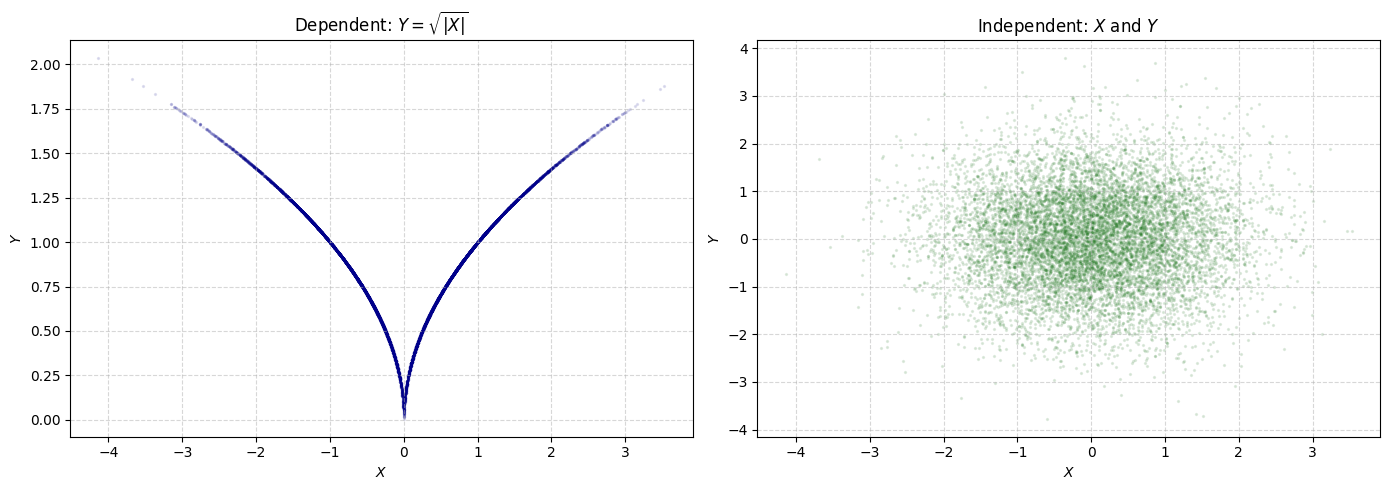

In [3]:
# Generate X
n = 10000
x = np.random.randn(n)
# Dependent Y: Y is directly determined by X
y_dependent = np.sqrt(np.abs(x))
# Independent Y: generated separately from X
y_independent = np.random.randn(n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(x, y_dependent, alpha=0.1, s=2, color='darkblue')
ax1.set_title('Dependent: $Y = \\sqrt{|X|}$')
ax1.set_xlabel('$X$')
ax1.set_ylabel('$Y$')
ax1.grid(True, linestyle='--', alpha=0.5)
ax2.scatter(x, y_independent, alpha=0.1, s=2, color='darkgreen')
ax2.set_title('Independent: $X$ and $Y$')
ax2.set_xlabel('$X$')
ax2.set_ylabel('$Y$')
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 2.3.2 Correlation and Dependence
Correlations are useful because they can indicate a predictive relationship that can be exploited in practice. **Covariance** is a measure of the joint variability of two random variables.

### 2.3.2.1 Correlation for Random Variables

**Definition 2.3.9.** Let $X$ and $Y$ be jointly distributed random variables with pmf $p(x, y)$ or pdf $f(x, y)$ according to whether the variables are discrete or continuous. The **covariance** between two random variables $X$ and $Y$ is:

$$ \text{Cov}(X, Y) = E [(X - \mu_X)(Y - \mu_Y)] $$

$$ \text{Cov}(X, Y) =
\begin{cases}
\sum_{x} \sum_{y} (x - \mu_X)(y - \mu_Y) p(x, y), & X, Y \text{ discrete} \\
\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} (x - \mu_X)(y - \mu_Y) f(x, y) \, dx \, dy, & X, Y \text{ continuous}
\end{cases} $$

Since $X - \mu_X$ and $Y - \mu_Y$ are the deviations of the two variables from their respective mean values, the covariance is the expected product of deviations.

> **Note:** $\text{Cov}(X, X) = E [(X - \mu_X)^2] = V(X)$.

The **correlation coefficient** is the covariance of the two variables divided by the product of their standard deviations, which is a measure of linear correlation between two variables or sets of data.

**Definition 2.3.10.** The **correlation coefficient** of $X$ and $Y$, denoted by $\text{Corr}(X, Y)$, $\rho_{X,Y}$, or just $\rho$, is defined by:

$$ \rho_{X,Y} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y} $$

**Proposition 2.3.11.** Correlation coefficients have the following properties:
1. If $X$ and $Y$ are independent, then $\rho = 0$. However, $\rho = 0$ **does not imply** independence.
2. $|\rho| \le 1$. Further, $\rho = 1$ or $-1$ if and only if $Y = aX + b$ for some constants $a$ and $b$ where $a \neq 0$.

### 2.3.2.2 Correlation for Samples
The correlation coefficient, when applied to a sample, is commonly represented by $r_{xy}$. Given paired data $\{(x_1, y_1), \dots, (x_n, y_n)\}$ consisting of $n$ pairs:

$$ r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}} $$

where $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ is the sample mean (and analogously for $\bar{y}$).

**Proposition 2.3.12.** The correlation coefficient for samples has the following properties:

* $r_{xy} = \frac{s_{xy}}{s_x s_y}$
  * where the **sample covariance** is:
    $$ s_{xy} = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y}) $$
  * and the **sample standard deviation** is:
    $$ s_x = \sqrt{\frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2} $$
* If $y = ax + b$, then $r_{xy} = 1$ if $a$ is positive, or $r_{xy} = -1$ if $a$ is negative.


Dependent nonlinear relationship:
Covariance: -0.0005151557414675975
Correlation: -0.0014766363807759049
Is correlation close to zero? Yes

Independent variables:
Covariance: -0.004929857024696486
Correlation: -0.004948734166677081
Is correlation close to zero? Yes

Perfect linear relationship:
Covariance: 2.001489863590784
Correlation: 1.0
Is correlation close to zero? No


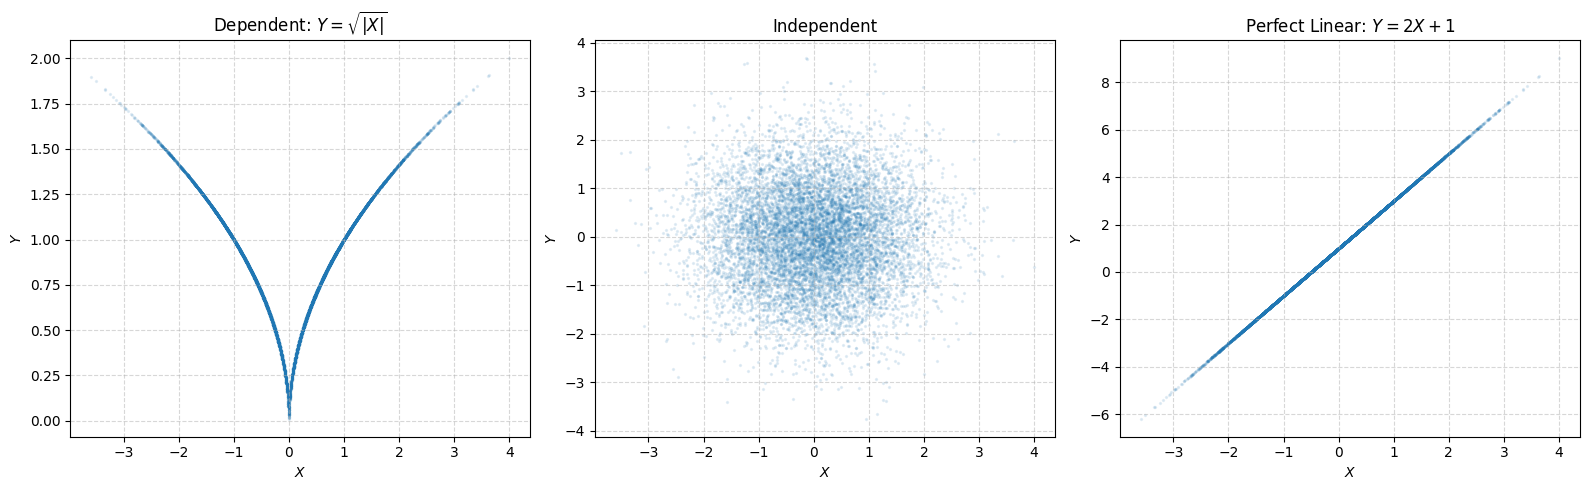

In [4]:
def is_corr_close_to_zero(x, y, tolerance=0.05):
    corr = np.corrcoef(x, y)[0, 1]

    if np.isclose(corr, 0, atol=tolerance):
        return "Yes"
    else:
        return "No"
n = 10000
# X
x = np.random.randn(n)
# Y1: dependent on X
y_dependent = np.sqrt(np.abs(x))
# Y2: independent of X
y_independent = np.random.randn(n)
# Y3: linearly dependent on X
y_linear = 2*x + 1

print("Dependent nonlinear relationship:")
print("Covariance:", np.cov(x, y_dependent)[0, 1])
print("Correlation:", np.corrcoef(x, y_dependent)[0, 1])
print("Is correlation close to zero?",
      is_corr_close_to_zero(x, y_dependent))
print("\nIndependent variables:")
print("Covariance:", np.cov(x, y_independent)[0, 1])
print("Correlation:", np.corrcoef(x, y_independent)[0, 1])
print("Is correlation close to zero?",
      is_corr_close_to_zero(x, y_independent))
print("\nPerfect linear relationship:")
print("Covariance:", np.cov(x, y_linear)[0, 1])
print("Correlation:", np.corrcoef(x, y_linear)[0, 1])
print("Is correlation close to zero?",
      is_corr_close_to_zero(x, y_linear))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(x, y_dependent, alpha=0.1, s=2)
axes[0].set_title(r'Dependent: $Y=\sqrt{|X|}$')
axes[0].set_xlabel('$X$')
axes[0].set_ylabel('$Y$')
axes[1].scatter(x, y_independent, alpha=0.1, s=2)
axes[1].set_title('Independent')
axes[1].set_xlabel('$X$')
axes[1].set_ylabel('$Y$')
axes[2].scatter(x, y_linear, alpha=0.1, s=2)
axes[2].set_title(r'Perfect Linear: $Y=2X+1$')
axes[2].set_xlabel('$X$')
axes[2].set_ylabel('$Y$')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2.3.3 Random Samples

### 2.3.3.1 Random Samples

**Definition 2.3.13.** The random variables $X_1, X_2, \dots, X_n$ are said to form a **(simple) random sample** of size $n$ if:
1. The $X_i$’s are independent random variables.
2. Every $X_i$ has the same probability distribution.

**Proposition 2.3.14.** Let $X_1, X_2, \dots, X_n$ be a random sample from a distribution with mean value $\mu$ and standard deviation $\sigma$. Then for the sample mean $\bar{X}$:
1. $E(\bar{X}) = \mu_{\bar{X}} = \mu$
2. $V(\bar{X}) = \sigma^2_{\bar{X}} = \frac{\sigma^2}{n}$ and $\sigma_{\bar{X}} = \frac{\sigma}{\sqrt{n}}$

In addition, for the sample total $T_o = X_1 + \dots + X_n$:
* $E(T_o) = n\mu$
* $V(T_o) = n\sigma^2$
* $\sigma_{T_o} = \sqrt{n}\sigma$

### 2.3.3.2 The Central Limit Theorem

The **Central Limit Theorem (CLT)** indicates that the properly normalized sum of independent random variables tends toward a normal distribution even if the original variables themselves are not normally distributed.

**Theorem 2.3.15 (The Central Limit Theorem (CLT)).** Let $X_1, X_2, \dots, X_n$ be a random sample from a distribution with mean $\mu$ and variance $\sigma^2$. Then if $n$ is sufficiently large:

* $\bar{X}$ has approximately a normal distribution with:
  $$ \mu_{\bar{X}} = \mu \quad \text{and} \quad \sigma^2_{\bar{X}} = \frac{\sigma^2}{n} $$
* $T_o$ also has approximately a normal distribution with:
  $$ \mu_{T_o} = n\mu \quad \text{and} \quad \sigma^2_{T_o} = n\sigma^2 $$

The larger the value of $n$, the better the approximation.


1: A Random Sample
Sample: [12.47235282 11.32795856 11.21870395  9.75973483 10.3107331   9.02322869
  8.98005556 10.63343286  2.64863795  8.4866048   8.70298905  8.92841301
 11.85558429  8.83193231 10.25421066 11.48553753 12.59259811  9.62139588
 11.92659322 11.184637   13.54233988 11.31146865  6.1942677   3.11282354
 14.42417081  9.24884599  8.83483442 12.08305437 11.86248132 11.16095424]
Sample mean: 10.067352503885067
Sample standard deviation: 2.6052555235116612
Theoretical SE of X-bar: 0.5477225575051661

2: Sampling of Distrobution of X
Mean of sample means: 9.991245552664909
SD of sample means: 0.5457271547061376
Theoretical SE: 0.5477225575051661


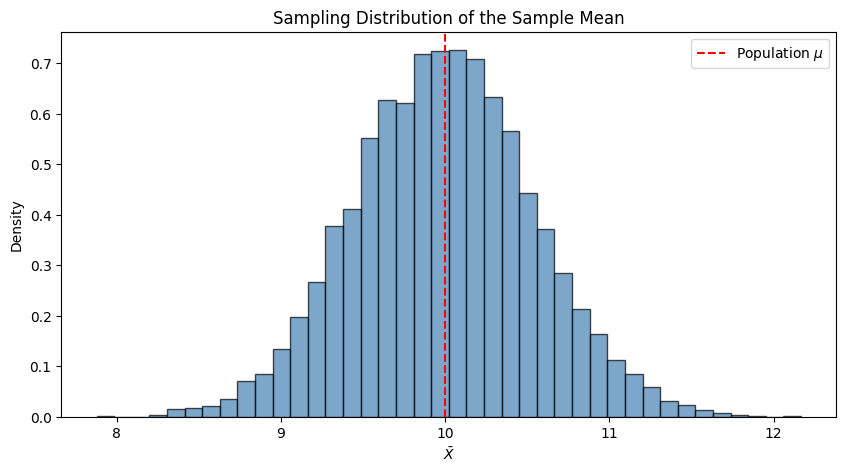

3: Central Limit THM


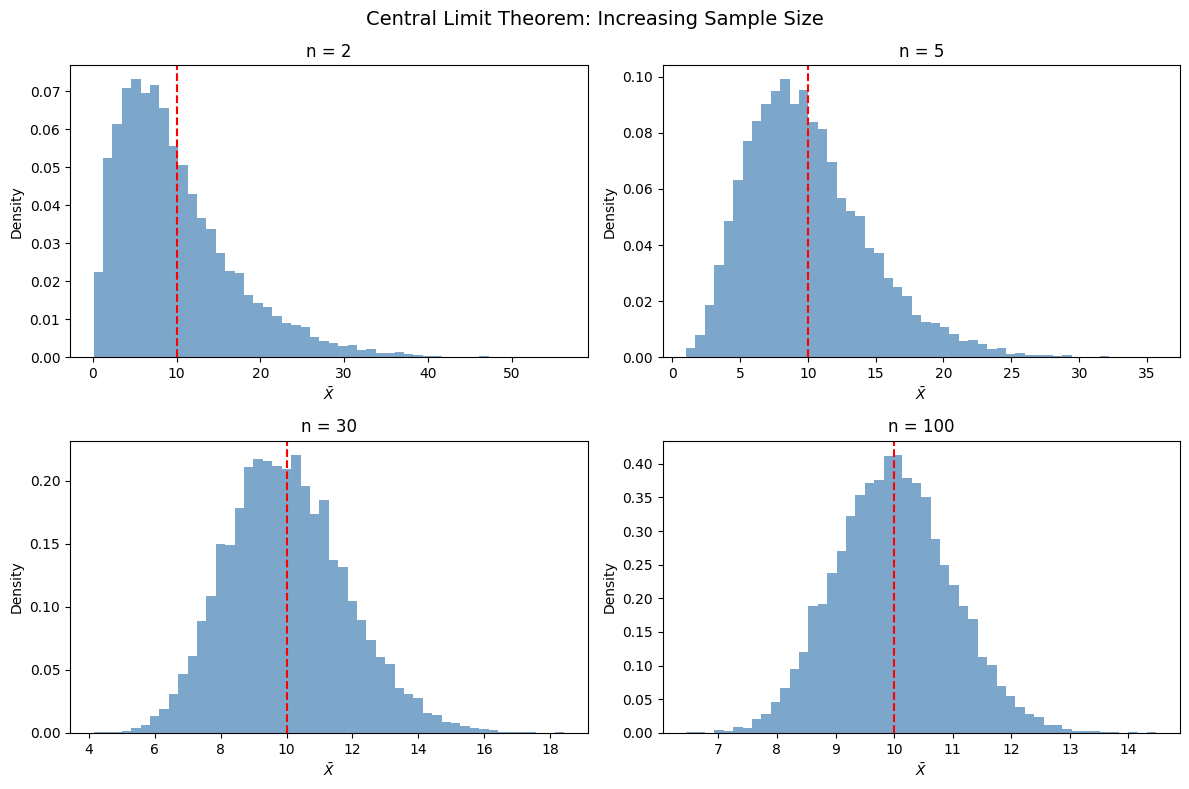

In [5]:
# Population parameters
mu = 10
sigma = 3

# 1: One random Sample
n = 30
sample = np.random.normal(mu, sigma, n)
print("1: A Random Sample")
print("Sample:", sample)
print("Sample mean:", np.mean(sample))
print("Sample standard deviation:", np.std(sample, ddof=1))
theoretical_se = sigma / np.sqrt(n)
print("Theoretical SE of X-bar:", theoretical_se)

# 2: Sampling of distro. of X-bar
num_samples = 10000
samples = np.random.normal(
    mu,
    sigma,
    (num_samples, n)
)
sample_means = np.mean(samples, axis=1)
print("\n2: Sampling of Distrobution of X")
print("Mean of sample means:",
      np.mean(sample_means))
print("SD of sample means:",
      np.std(sample_means, ddof=1))
print("Theoretical SE:",
      sigma / np.sqrt(n))
plt.figure(figsize=(10, 5))
plt.hist(
    sample_means,
    bins=40,
    density=True,
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)
plt.axvline(
    mu,
    color='red',
    linestyle='--',
    label=r'Population $\mu$'
)
plt.title('Sampling Distribution of the Sample Mean')
plt.xlabel(r'$\bar{X}$')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3: Central Limit THM
print("3: Central Limit THM")
sample_sizes = [2, 5, 30, 100]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, n in zip(axes.flatten(), sample_sizes):
    samples = np.random.exponential(
        scale=mu,
        size=(num_samples, n)
    )
    sample_means = np.mean(samples, axis=1)
    ax.hist(
        sample_means,
        bins=50,
        density=True,
        color='steelblue',
        alpha=0.7
    )
    ax.axvline(
        mu,
        color='red',
        linestyle='--'
    )
    ax.set_title(f'n = {n}')
    ax.set_xlabel(r'$\bar{X}$')
    ax.set_ylabel('Density')
plt.suptitle(
    'Central Limit Theorem: Increasing Sample Size',
    fontsize=14
)
plt.tight_layout()
plt.show()